In [1]:
# ============================================================
# 1. Imports
# ============================================================

import os
import gc
import json
import math
import time
import shutil
import random
import hashlib
import platform
import datetime as dt
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)
from sklearn.calibration import calibration_curve

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA available: True


In [2]:
# ============================================================
# 2. Central configuration
# ============================================================

CONFIG = {
    # Experiment identity
    "project_name": "extremism_text_classification",
    "technique_name": "SLP_TF-IDF",
    "model_family": "single_layer_perceptron",
    "feature_family": "tfidf_word",
    "dataset_version": "extremism_dataset_clean_v1",
    "split_version": "split_v1",
    "random_seed": 30,

    # Paths from your Kaggle foundation notebook output.
    # These are set to match your current Kaggle workflow.
    "processed_dataset_path": "/kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv",
    "split_assignments_path": "/kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv",
    "dataset_manifest_path": "/kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json",

    # Required columns from 00_create_dataset_and_splits.ipynb
    "id_col": "row_id",
    "text_col": "text",
    "label_col": "label",
    "split_col": "split",
    "positive_label": 1,

    # Output
    "output_root": "/kaggle/working/experiments",
    "overwrite_output_dir": True,

    # SLP ablation / tuning.
    # Keep this moderate because PyTorch SLP requires dense TF-IDF matrices.
    "ablation_grid": {
        "max_features": [10000, 20000],
        "ngram_range": [[1, 1], [1, 2]],
        "min_df": [1, 2],
        "max_df": [0.95],
        "sublinear_tf": [True],
        "learning_rate": [0.001, 0.0005],
        "weight_decay": [0.0001, 0.001],
        "batch_size": [32, 64],
        "use_pos_weight": [True],
    },

    # Training settings
    "training": {
        "epochs": 30,
        "early_stopping_patience": 5,
        "early_stopping_min_delta": 0.0,
        "shuffle_train_loader": True,
        "num_workers": 0,
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "dense_matrix_memory_limit_gb": 4.0,
    },

    # Thresholding
    "threshold_strategy": "maximize_val_f1",
    "threshold_grid": {
        "start": 0.01,
        "stop": 0.99,
        "num": 99,
    },

    # Explainability
    # This notebook saves two explanation styles:
    # 1. exact direct linear logit contributions: weight * tfidf
    # 2. SHAP-style/background-adjusted linear attributions: weight * (tfidf - train_mean_tfidf)
    "explainability": {
        "top_n_global": 100,
        "top_k_local_features": 15,
        "max_local_examples_total": 120,
        "include_text_preview": False,
        "text_preview_chars": 240,

        "compute_direct_linear_contributions": True,
        "compute_background_adjusted_linear_attributions": True,
        "background_split": "train",
        "background_adjusted_method_name": "shap_style_linear_background_adjusted",
        "background_adjusted_include_absent_features_for_local": True,
    },

    # Error analysis
    "error_analysis": {
        "examples_per_bucket": 25,
        "near_threshold_margin": 0.05,
        "include_text_preview": False,
        "text_preview_chars": 240,
    },
}

TECHNIQUE_NAME = CONFIG["technique_name"]
OUTPUT_DIR = Path(CONFIG["output_root"]) / TECHNIQUE_NAME

print("Technique:", TECHNIQUE_NAME)
print("Output directory:", OUTPUT_DIR)
print("Device:", CONFIG["training"]["device"])

Technique: SLP_TF-IDF
Output directory: /kaggle/working/experiments/SLP_TF-IDF
Device: cuda


In [3]:
# ============================================================
# 3. Reproducibility and helper functions
# ============================================================

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_json_safe(obj):
    """Convert numpy/torch/path objects into JSON-serializable Python objects."""
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        value = float(obj)
        return None if math.isnan(value) else value
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, torch.Tensor):
        return obj.detach().cpu().numpy().tolist()
    try:
        if pd.isna(obj) and not isinstance(obj, (list, tuple, dict, np.ndarray)):
            return None
    except Exception:
        pass
    return obj


def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(make_json_safe(obj), f, indent=2)


def sha256_file(path: Path, n_chars: int = 16) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()[:n_chars]


def sha256_text(text: str, n_chars: int = 16) -> str:
    return hashlib.sha256(str(text).encode("utf-8")).hexdigest()[:n_chars]


def find_file_by_name(file_name: str, search_roots=None) -> Path:
    """Find a file under common Kaggle locations. Raises a clear error if not found."""
    if search_roots is None:
        search_roots = [Path("/kaggle/input"), Path("/kaggle/working"), Path(".")]

    matches = []
    for root in search_roots:
        if root.exists():
            matches.extend(root.rglob(file_name))

    matches = sorted(set(matches), key=lambda p: (len(str(p)), str(p)))

    if len(matches) == 0:
        raise FileNotFoundError(
            f"Could not find {file_name}. Set the relevant CONFIG path manually."
        )

    print(f"Found {file_name}:")
    for m in matches[:10]:
        print(" -", m)
    if len(matches) > 1:
        print(f"Using first match: {matches[0]}")
    return matches[0]


def initialize_output_dir(output_dir: Path, overwrite: bool = True) -> None:
    if output_dir.exists() and overwrite:
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for subdir in [
        "model_artifacts",
        "plots",
        "interpretability",
        "error_analysis",
        "ablation",
    ]:
        (output_dir / subdir).mkdir(parents=True, exist_ok=True)


set_global_seed(CONFIG["random_seed"])
initialize_output_dir(OUTPUT_DIR, CONFIG["overwrite_output_dir"])
save_json(CONFIG, OUTPUT_DIR / "config.json")

RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')}"
print("Run ID:", RUN_ID)
print("Initialized output directory.")

Run ID: SLP_TF-IDF_20260620T232103Z
Initialized output directory.


/tmp/ipykernel_22/3671530220.py:102: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  RUN_ID = f"{TECHNIQUE_NAME}_{dt.datetime.utcnow().strftime('%Y%m%dT%H%M%SZ')}"


In [4]:
# ============================================================
# 4. Load processed dataset, split assignments, and manifest
# ============================================================

processed_dataset_path = (
    Path(CONFIG["processed_dataset_path"])
    if CONFIG["processed_dataset_path"] is not None
    else find_file_by_name("processed_dataset.csv")
)

split_assignments_path = (
    Path(CONFIG["split_assignments_path"])
    if CONFIG["split_assignments_path"] is not None
    else find_file_by_name("split_assignments.csv")
)

if CONFIG["dataset_manifest_path"] is not None:
    dataset_manifest_path = Path(CONFIG["dataset_manifest_path"])
else:
    try:
        dataset_manifest_path = find_file_by_name("dataset_manifest.json")
    except FileNotFoundError:
        dataset_manifest_path = None

if not processed_dataset_path.exists():
    raise FileNotFoundError(f"Processed dataset not found: {processed_dataset_path}")
if not split_assignments_path.exists():
    raise FileNotFoundError(f"Split assignments not found: {split_assignments_path}")

df = pd.read_csv(processed_dataset_path)
splits = pd.read_csv(split_assignments_path)

print("Processed dataset path:", processed_dataset_path)
print("Split assignments path:", split_assignments_path)
print("Dataset shape:", df.shape)
print("Splits shape:", splits.shape)

display(df.head())
display(splits.head())

dataset_manifest = {}
if dataset_manifest_path is not None and dataset_manifest_path.exists():
    with open(dataset_manifest_path, "r") as f:
        dataset_manifest = json.load(f)
    print("Loaded dataset manifest:", dataset_manifest_path)
else:
    print("No dataset manifest found. Continuing without it.")

Processed dataset path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/processed_dataset.csv
Split assignments path: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/split_assignments.csv
Dataset shape: (2999, 8)
Splits shape: (2999, 4)


,row_id,original_index,text,label,raw_label,text_hash,char_len,word_len
0,ex_000000,0,sixth forms should burn to the ground,1,EXTREMIST,e0cc81a4d5f0f2b3,37,7
1,ex_000001,1,whatever should burn benders to the ground,1,EXTREMIST,906f97390ef91f64,42,7
2,ex_000002,2,factories should burn to the ground,1,EXTREMIST,50fe44bc8cf60d1c,35,6
3,ex_000003,3,halal factories should burn to the ground,1,EXTREMIST,4bedb3fea5ed5fbe,41,7
4,ex_000004,4,nhs should burn to the ground,1,EXTREMIST,f1a8b2543327a925,29,6


,row_id,label,text_hash,split
0,ex_000000,1,e0cc81a4d5f0f2b3,test
1,ex_000001,1,906f97390ef91f64,train
2,ex_000002,1,50fe44bc8cf60d1c,test
3,ex_000003,1,4bedb3fea5ed5fbe,test
4,ex_000004,1,f1a8b2543327a925,train


Loaded dataset manifest: /kaggle/input/notebooks/anthony73/extremism-research-dataset-creation-splits-nb/research_foundation/dataset_manifest.json


In [5]:
# ============================================================
# 5. Validate schema and apply canonical split
# ============================================================

id_col = CONFIG["id_col"]
text_col = CONFIG["text_col"]
label_col = CONFIG["label_col"]
split_col = CONFIG["split_col"]

required_df_cols = {id_col, text_col, label_col}
required_split_cols = {id_col, split_col}

missing_df_cols = required_df_cols - set(df.columns)
missing_split_cols = required_split_cols - set(splits.columns)

if missing_df_cols:
    raise ValueError(f"Processed dataset is missing required columns: {missing_df_cols}")
if missing_split_cols:
    raise ValueError(f"Split assignments are missing required columns: {missing_split_cols}")

# Defensive cleaning.
df = df.copy()
df[text_col] = df[text_col].fillna("").astype(str)
df[label_col] = df[label_col].astype(int)

# Ensure text_hash exists, but do not expose raw text in saved predictions by default.
if "text_hash" not in df.columns:
    df["text_hash"] = df[text_col].apply(sha256_text)

# Apply split file.
df = df.merge(splits[[id_col, split_col]], on=id_col, how="left", validate="one_to_one")

if df[split_col].isna().any():
    missing = int(df[split_col].isna().sum())
    raise ValueError(f"{missing} rows in processed_dataset.csv do not have split assignments.")

expected_splits = {"train", "validation", "test"}
actual_splits = set(df[split_col].unique())
if actual_splits != expected_splits:
    raise ValueError(f"Expected splits {expected_splits}, found {actual_splits}")

train_df = df[df[split_col] == "train"].copy()
val_df = df[df[split_col] == "validation"].copy()
test_df = df[df[split_col] == "test"].copy()

print("Split sizes:")
display(df[split_col].value_counts().to_frame("count"))

print("\nLabel distribution by split:")
split_label_table = (
    df.groupby([split_col, label_col])
    .size()
    .reset_index(name="count")
)
split_sizes = df.groupby(split_col).size().rename("split_count").reset_index()
split_label_table = split_label_table.merge(split_sizes, on=split_col)
split_label_table["proportion"] = split_label_table["count"] / split_label_table["split_count"]
display(split_label_table)

assert train_df[id_col].is_unique
assert val_df[id_col].is_unique
assert test_df[id_col].is_unique
assert set(train_df[id_col]).isdisjoint(set(val_df[id_col]))
assert set(train_df[id_col]).isdisjoint(set(test_df[id_col]))
assert set(val_df[id_col]).isdisjoint(set(test_df[id_col]))

print("Split validation passed.")

Split sizes:


,count
split,
train,2099
test,450
validation,450



Label distribution by split:


,split,label,count,split_count,proportion
0,test,0,240,450,0.533333
1,test,1,210,450,0.466667
2,train,0,1121,2099,0.534064
3,train,1,978,2099,0.465936
4,validation,0,241,450,0.535556
5,validation,1,209,450,0.464444


Split validation passed.


In [6]:
# ============================================================
# 6. Metric and threshold helpers
# ============================================================

def safe_roc_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return None
        return float(roc_auc_score(y_true, y_prob))
    except Exception:
        return None


def safe_pr_auc(y_true, y_prob):
    try:
        if len(np.unique(y_true)) < 2:
            return None
        return float(average_precision_score(y_true, y_prob))
    except Exception:
        return None


def compute_binary_metrics(y_true, y_prob, y_pred, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = np.asarray(y_pred).astype(int)

    labels = [0, 1]
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=labels).ravel()

    metrics = {
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "positive_precision": float(precision_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "positive_recall": float(recall_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "positive_f1": float(f1_score(y_true, y_pred, pos_label=1, zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "roc_auc": safe_roc_auc(y_true, y_prob),
        "pr_auc": safe_pr_auc(y_true, y_prob),
        "brier_score": float(brier_score_loss(y_true, y_prob)),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else None,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else None,
        "support": int(len(y_true)),
        "positive_support": int(y_true.sum()),
        "negative_support": int(len(y_true) - y_true.sum()),
        "positive_rate": float(y_true.mean()),
    }
    return metrics


def threshold_candidates():
    grid = CONFIG["threshold_grid"]
    return np.linspace(grid["start"], grid["stop"], grid["num"])


def choose_threshold(y_true, y_prob, strategy="maximize_val_f1"):
    thresholds = threshold_candidates()

    if strategy == "fixed_0.5":
        return 0.5, {"threshold_strategy": strategy, "selection_metric": None, "selection_value": None}

    rows = []
    for t in thresholds:
        y_pred = (np.asarray(y_prob) >= t).astype(int)
        rows.append({
            "threshold": float(t),
            "positive_f1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
            "positive_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            "positive_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        })

    threshold_df = pd.DataFrame(rows)

    if strategy == "maximize_val_f1":
        best_row = threshold_df.sort_values(
            ["positive_f1", "positive_recall", "positive_precision"],
            ascending=[False, False, False],
        ).iloc[0]
        selected = float(best_row["threshold"])
        details = {
            "threshold_strategy": strategy,
            "selection_metric": "positive_f1",
            "selection_value": float(best_row["positive_f1"]),
            "threshold_table": threshold_df.to_dict(orient="records"),
        }
        return selected, details

    raise ValueError(f"Unknown threshold strategy: {strategy}")


def make_prediction_frame(split_df, split_name, y_prob, threshold, run_id):
    y_true = split_df[label_col].astype(int).to_numpy()
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)

    pred_df = pd.DataFrame({
        "run_id": run_id,
        "technique": TECHNIQUE_NAME,
        "row_id": split_df[id_col].values,
        "split": split_name,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": np.asarray(y_prob),
        "y_prob": np.asarray(y_prob),
        "threshold": float(threshold),
        "correct": y_true == y_pred,
        "text_hash": split_df["text_hash"].values,
    })

    conditions = [
        (pred_df["y_true"] == 0) & (pred_df["y_pred"] == 0),
        (pred_df["y_true"] == 0) & (pred_df["y_pred"] == 1),
        (pred_df["y_true"] == 1) & (pred_df["y_pred"] == 0),
        (pred_df["y_true"] == 1) & (pred_df["y_pred"] == 1),
    ]
    choices = ["true_negative", "false_positive", "false_negative", "true_positive"]
    pred_df["error_type"] = np.select(conditions, choices, default="unknown")

    return pred_df

print("Metric and threshold helpers ready.")

Metric and threshold helpers ready.


In [7]:
# ============================================================
# 7. PyTorch SLP model and training helpers
# ============================================================

class SLPTextClassifier(nn.Module):
    """Single-layer perceptron: a linear classifier over TF-IDF features."""
    def __init__(self, input_dim: int):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze(1)


def estimate_dense_gb(n_rows: int, n_features: int, dtype_bytes: int = 4) -> float:
    return (n_rows * n_features * dtype_bytes) / (1024 ** 3)


def sparse_to_float_tensor(X_sparse, name="matrix"):
    n_rows, n_features = X_sparse.shape
    estimated_gb = estimate_dense_gb(n_rows, n_features)
    limit_gb = CONFIG["training"]["dense_matrix_memory_limit_gb"]
    print(f"{name}: {X_sparse.shape}, dense float32 estimate = {estimated_gb:.3f} GB")
    if estimated_gb > limit_gb:
        raise MemoryError(
            f"Dense conversion of {name} would require about {estimated_gb:.2f} GB, "
            f"above configured limit {limit_gb:.2f} GB. Reduce max_features or batch size."
        )
    return torch.tensor(X_sparse.toarray(), dtype=torch.float32)


def build_loader(X_tensor, y_tensor, batch_size, shuffle):
    ds = TensorDataset(X_tensor, y_tensor)
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=CONFIG["training"]["num_workers"],
    )


def predict_proba_torch(model, X_tensor, batch_size=512, device="cpu"):
    model.eval()
    probs = []
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            logits = model(xb)
            batch_probs = torch.sigmoid(logits).detach().cpu().numpy()
            probs.append(batch_probs)
    return np.concatenate(probs)


def train_slp_model(X_train_tensor, y_train_tensor, X_val_tensor, y_val, train_config, input_dim):
    device = CONFIG["training"]["device"]
    model = SLPTextClassifier(input_dim=input_dim).to(device)

    if train_config["use_pos_weight"]:
        y_train_np = y_train_tensor.numpy().astype(int)
        num_pos = max(int(y_train_np.sum()), 1)
        num_neg = max(int(len(y_train_np) - y_train_np.sum()), 1)
        pos_weight_value = num_neg / num_pos
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(device)
    else:
        pos_weight_value = None
        pos_weight = None

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=train_config["learning_rate"],
        weight_decay=train_config["weight_decay"],
    )

    train_loader = build_loader(
        X_train_tensor,
        y_train_tensor.float(),
        batch_size=train_config["batch_size"],
        shuffle=CONFIG["training"]["shuffle_train_loader"],
    )

    best_state = None
    best_epoch = None
    best_val_f1 = -1.0
    best_val_threshold = 0.5
    best_val_metrics = None
    best_val_probs = None
    epochs_without_improvement = 0
    history = []

    epochs = CONFIG["training"]["epochs"]
    patience = CONFIG["training"]["early_stopping_patience"]
    min_delta = CONFIG["training"]["early_stopping_min_delta"]

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        n_seen = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)
            n_seen += xb.size(0)

        train_loss = total_loss / max(n_seen, 1)
        val_probs = predict_proba_torch(
            model,
            X_val_tensor,
            batch_size=512,
            device=device,
        )
        val_threshold, threshold_details = choose_threshold(
            y_val,
            val_probs,
            strategy=CONFIG["threshold_strategy"],
        )
        val_preds = (val_probs >= val_threshold).astype(int)
        val_metrics = compute_binary_metrics(y_val, val_probs, val_preds, val_threshold)

        row = {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_threshold": float(val_threshold),
            "val_positive_f1": val_metrics["positive_f1"],
            "val_positive_precision": val_metrics["positive_precision"],
            "val_positive_recall": val_metrics["positive_recall"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_roc_auc": val_metrics["roc_auc"],
        }
        history.append(row)

        improved = val_metrics["positive_f1"] > best_val_f1 + min_delta
        if improved:
            best_val_f1 = val_metrics["positive_f1"]
            best_epoch = epoch
            best_val_threshold = val_threshold
            best_val_metrics = val_metrics
            best_val_probs = val_probs.copy()
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        "model": model,
        "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "best_val_f1": best_val_f1,
        "best_val_threshold": best_val_threshold,
        "best_val_metrics": best_val_metrics,
        "best_val_probs": best_val_probs,
        "pos_weight_value": pos_weight_value,
    }
    return result

print("SLP model and training helpers ready.")

SLP model and training helpers ready.


In [8]:
# ============================================================
# 8. Build validation-only ablation grid
# ============================================================

def expand_ablation_grid(grid_dict):
    keys = list(grid_dict.keys())
    values = [grid_dict[k] for k in keys]
    configs = []
    for i, combo in enumerate(product(*values), start=1):
        cfg = dict(zip(keys, combo))
        cfg["config_index"] = i
        configs.append(cfg)
    return configs

ablation_configs = expand_ablation_grid(CONFIG["ablation_grid"])
print(f"Number of SLP validation-only ablation configurations: {len(ablation_configs)}")
display(pd.DataFrame(ablation_configs).head())

Number of SLP validation-only ablation configurations: 64


,max_features,ngram_range,min_df,max_df,sublinear_tf,learning_rate,weight_decay,batch_size,use_pos_weight,config_index
0,10000,"[1, 1]",1,0.95,True,0.0010,0.0001,32,True,1
1,10000,"[1, 1]",1,0.95,True,0.0010,0.0001,64,True,2
2,10000,"[1, 1]",1,0.95,True,0.0010,0.0010,32,True,3
3,10000,"[1, 1]",1,0.95,True,0.0010,0.0010,64,True,4
4,10000,"[1, 1]",1,0.95,True,0.0005,0.0001,32,True,5


In [9]:
# ============================================================
# 9. Run validation-only ablations
# ============================================================

X_train_text = train_df[text_col].astype(str).tolist()
X_val_text = val_df[text_col].astype(str).tolist()
y_train = train_df[label_col].astype(int).to_numpy()
y_val = val_df[label_col].astype(int).to_numpy()

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

ablation_rows = []
best_ablation = None
best_ablation_score = -1.0
best_ablation_tiebreak_pr_auc = -1.0

start_time = time.time()

for cfg in ablation_configs:
    cfg_start = time.time()
    print("\n" + "=" * 70)
    print(f"Running ablation config {cfg['config_index']}/{len(ablation_configs)}: {cfg}")

    vectorizer = TfidfVectorizer(
        max_features=cfg["max_features"],
        ngram_range=tuple(cfg["ngram_range"]),
        min_df=cfg["min_df"],
        max_df=cfg["max_df"],
        sublinear_tf=cfg["sublinear_tf"],
        lowercase=True,
        strip_accents="unicode",
    )

    X_train_vec = vectorizer.fit_transform(X_train_text)
    X_val_vec = vectorizer.transform(X_val_text)

    X_train_tensor = sparse_to_float_tensor(X_train_vec, name="X_train_vec")
    X_val_tensor = sparse_to_float_tensor(X_val_vec, name="X_val_vec")

    train_config = {
        "learning_rate": cfg["learning_rate"],
        "weight_decay": cfg["weight_decay"],
        "batch_size": cfg["batch_size"],
        "use_pos_weight": cfg["use_pos_weight"],
    }

    set_global_seed(CONFIG["random_seed"])
    train_result = train_slp_model(
        X_train_tensor=X_train_tensor,
        y_train_tensor=y_train_tensor,
        X_val_tensor=X_val_tensor,
        y_val=y_val,
        train_config=train_config,
        input_dim=X_train_vec.shape[1],
    )

    val_probs = train_result["best_val_probs"]
    val_threshold = train_result["best_val_threshold"]
    val_preds = (val_probs >= val_threshold).astype(int)
    val_metrics = compute_binary_metrics(y_val, val_probs, val_preds, val_threshold)

    row = {
        **cfg,
        "best_epoch": train_result["best_epoch"],
        "epochs_trained": int(len(train_result["history"])),
        "pos_weight_value": train_result["pos_weight_value"],
        "val_threshold": val_threshold,
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_positive_precision": val_metrics["positive_precision"],
        "val_positive_recall": val_metrics["positive_recall"],
        "val_positive_f1": val_metrics["positive_f1"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_weighted_f1": val_metrics["weighted_f1"],
        "val_roc_auc": val_metrics["roc_auc"],
        "val_pr_auc": val_metrics["pr_auc"],
        "val_brier_score": val_metrics["brier_score"],
        "val_tn": val_metrics["tn"],
        "val_fp": val_metrics["fp"],
        "val_fn": val_metrics["fn"],
        "val_tp": val_metrics["tp"],
        "runtime_seconds": time.time() - cfg_start,
    }
    ablation_rows.append(row)

    pd.DataFrame(ablation_rows).to_csv(OUTPUT_DIR / "ablation" / "ablation_results_partial.csv", index=False)

    score = val_metrics["positive_f1"]
    pr_auc_tiebreak = val_metrics["pr_auc"] if val_metrics["pr_auc"] is not None else -1.0

    if (score > best_ablation_score) or (
        np.isclose(score, best_ablation_score) and pr_auc_tiebreak > best_ablation_tiebreak_pr_auc
    ):
        best_ablation_score = score
        best_ablation_tiebreak_pr_auc = pr_auc_tiebreak
        best_ablation = {
            "config": cfg.copy(),
            "train_config": train_config.copy(),
            "val_metrics": val_metrics,
            "best_epoch": train_result["best_epoch"],
            "epochs_trained": int(len(train_result["history"])),
            "pos_weight_value": train_result["pos_weight_value"],
        }

    # Release dense matrices before the next config.
    del vectorizer, X_train_vec, X_val_vec, X_train_tensor, X_val_tensor, train_result
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

ablation_results = pd.DataFrame(ablation_rows)
ablation_results = ablation_results.sort_values(
    ["val_positive_f1", "val_pr_auc", "val_positive_recall"],
    ascending=[False, False, False],
).reset_index(drop=True)

ablation_results.to_csv(OUTPUT_DIR / "ablation" / "ablation_results.csv", index=False)

print("\nFinished ablations.")
print(f"Total ablation time: {(time.time() - start_time) / 60:.2f} minutes")
print("Best validation config:")
display(ablation_results.head(10))

save_json(best_ablation, OUTPUT_DIR / "best_config.json")


Running ablation config 1/64: {'max_features': 10000, 'ngram_range': [1, 1], 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'use_pos_weight': True, 'config_index': 1}
X_train_vec: (2099, 6297), dense float32 estimate = 0.049 GB
X_val_vec: (450, 6297), dense float32 estimate = 0.011 GB

Running ablation config 2/64: {'max_features': 10000, 'ngram_range': [1, 1], 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 64, 'use_pos_weight': True, 'config_index': 2}
X_train_vec: (2099, 6297), dense float32 estimate = 0.049 GB
X_val_vec: (450, 6297), dense float32 estimate = 0.011 GB

Running ablation config 3/64: {'max_features': 10000, 'ngram_range': [1, 1], 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'learning_rate': 0.001, 'weight_decay': 0.001, 'batch_size': 32, 'use_pos_weight': True, 'config_index': 3}
X_train_vec: (2099, 6297), dense float32 estimate

,max_features,ngram_range,min_df,max_df,sublinear_tf,learning_rate,weight_decay,batch_size,use_pos_weight,config_index,...,val_macro_f1,val_weighted_f1,val_roc_auc,val_pr_auc,val_brier_score,val_tn,val_fp,val_fn,val_tp,runtime_seconds
0,10000,"[1, 1]",1,0.95,True,0.0010,0.0001,32,True,1,...,0.828699,0.829105,0.892712,0.886502,0.176071,194,47,30,179,23.682076
1,20000,"[1, 1]",1,0.95,True,0.0010,0.0001,32,True,33,...,0.828699,0.829105,0.892712,0.886502,0.176071,194,47,30,179,18.144297
2,10000,"[1, 2]",2,0.95,True,0.0010,0.0010,32,True,27,...,0.832731,0.833445,0.898271,0.893999,0.181356,201,40,35,174,15.806562
3,20000,"[1, 2]",2,0.95,True,0.0010,0.0010,32,True,59,...,0.832731,0.833445,0.898271,0.893999,0.181356,201,40,35,174,16.049933
4,10000,"[1, 2]",2,0.95,True,0.0005,0.0010,32,True,31,...,0.832731,0.833445,0.897496,0.893382,0.184844,201,40,35,174,22.770934
5,20000,"[1, 2]",2,0.95,True,0.0005,0.0010,32,True,63,...,0.832731,0.833445,0.897496,0.893382,0.184844,201,40,35,174,22.712406
6,10000,"[1, 2]",1,0.95,True,0.0010,0.0010,32,True,19,...,0.832638,0.833405,0.897080,0.893028,0.183692,202,39,36,173,15.245606
7,10000,"[1, 2]",2,0.95,True,0.0010,0.0001,32,True,25,...,0.830455,0.831205,0.896047,0.890642,0.165918,201,40,36,173,18.715018
8,20000,"[1, 2]",2,0.95,True,0.0010,0.0001,32,True,57,...,0.830455,0.831205,0.896047,0.890642,0.165918,201,40,36,173,19.288757
9,10000,"[1, 1]",1,0.95,True,0.0005,0.0010,32,True,7,...,0.822191,0.822359,0.890190,0.886229,0.212062,188,53,27,182,14.565343


In [10]:
# ============================================================
# 10. Train final selected model on train split and evaluate validation/test
# ============================================================

best_cfg = best_ablation["config"]
print("Selected config:")
print(best_cfg)

X_test_text = test_df[text_col].astype(str).tolist()
y_test = test_df[label_col].astype(int).to_numpy()

final_vectorizer = TfidfVectorizer(
    max_features=best_cfg["max_features"],
    ngram_range=tuple(best_cfg["ngram_range"]),
    min_df=best_cfg["min_df"],
    max_df=best_cfg["max_df"],
    sublinear_tf=best_cfg["sublinear_tf"],
    lowercase=True,
    strip_accents="unicode",
)

X_train_final = final_vectorizer.fit_transform(X_train_text)
X_val_final = final_vectorizer.transform(X_val_text)
X_test_final = final_vectorizer.transform(X_test_text)

feature_names = np.array(final_vectorizer.get_feature_names_out())
print("Final TF-IDF shapes:")
print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

X_train_tensor = sparse_to_float_tensor(X_train_final, name="X_train_final")
X_val_tensor = sparse_to_float_tensor(X_val_final, name="X_val_final")
X_test_tensor = sparse_to_float_tensor(X_test_final, name="X_test_final")
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

final_train_config = {
    "learning_rate": best_cfg["learning_rate"],
    "weight_decay": best_cfg["weight_decay"],
    "batch_size": best_cfg["batch_size"],
    "use_pos_weight": best_cfg["use_pos_weight"],
}

set_global_seed(CONFIG["random_seed"])
final_result = train_slp_model(
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_val_tensor=X_val_tensor,
    y_val=y_val,
    train_config=final_train_config,
    input_dim=X_train_final.shape[1],
)

final_model = final_result["model"]
training_history = final_result["history"]
training_history.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

# Select threshold using validation only.
val_probs = predict_proba_torch(final_model, X_val_tensor, batch_size=512, device=CONFIG["training"]["device"])
selected_threshold, threshold_details = choose_threshold(
    y_val,
    val_probs,
    strategy=CONFIG["threshold_strategy"],
)
val_preds = (val_probs >= selected_threshold).astype(int)
validation_metrics = compute_binary_metrics(y_val, val_probs, val_preds, selected_threshold)

# Final test evaluation: test is used once here.
test_probs = predict_proba_torch(final_model, X_test_tensor, batch_size=512, device=CONFIG["training"]["device"])
test_preds = (test_probs >= selected_threshold).astype(int)
test_metrics = compute_binary_metrics(y_test, test_probs, test_preds, selected_threshold)

validation_metrics.update({
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "split": "validation",
})

test_metrics.update({
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "split": "test",
    "selected_config_index": best_cfg["config_index"],
    "best_epoch": final_result["best_epoch"],
    "epochs_trained": int(len(training_history)),
    "pos_weight_value": final_result["pos_weight_value"],
})

save_json(validation_metrics, OUTPUT_DIR / "metrics_validation.json")
save_json(test_metrics, OUTPUT_DIR / "metrics_test.json")
save_json(threshold_details, OUTPUT_DIR / "model_artifacts" / "threshold_selection_details.json")
save_json({"threshold": selected_threshold}, OUTPUT_DIR / "model_artifacts" / "threshold.json")

print("Validation metrics:")
print(json.dumps(make_json_safe(validation_metrics), indent=2))
print("\nTest metrics:")
print(json.dumps(make_json_safe(test_metrics), indent=2))

Selected config:
{'max_features': 10000, 'ngram_range': [1, 1], 'min_df': 1, 'max_df': 0.95, 'sublinear_tf': True, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'batch_size': 32, 'use_pos_weight': True, 'config_index': 1}
Final TF-IDF shapes:
Train: (2099, 6297)
Validation: (450, 6297)
Test: (450, 6297)
X_train_final: (2099, 6297), dense float32 estimate = 0.049 GB
X_val_final: (450, 6297), dense float32 estimate = 0.011 GB
X_test_final: (450, 6297), dense float32 estimate = 0.011 GB
Validation metrics:
{
  "threshold": 0.48000000000000004,
  "accuracy": 0.8288888888888889,
  "balanced_accuracy": 0.830719291627787,
  "positive_precision": 0.7920353982300885,
  "positive_recall": 0.8564593301435407,
  "positive_f1": 0.8229885057471265,
  "macro_f1": 0.8286985539488321,
  "weighted_f1": 0.8291046018209534,
  "roc_auc": 0.8927117870118526,
  "pr_auc": 0.8865024670251317,
  "brier_score": 0.1760714616995837,
  "tn": 194,
  "fp": 47,
  "fn": 30,
  "tp": 179,
  "false_positive_rate": 0.195

In [11]:
# ============================================================
# 11. Save standardized predictions and classification reports
# ============================================================

validation_predictions = make_prediction_frame(
    val_df,
    split_name="validation",
    y_prob=val_probs,
    threshold=selected_threshold,
    run_id=RUN_ID,
)

test_predictions = make_prediction_frame(
    test_df,
    split_name="test",
    y_prob=test_probs,
    threshold=selected_threshold,
    run_id=RUN_ID,
)

validation_predictions.to_csv(OUTPUT_DIR / "predictions_validation.csv", index=False)
test_predictions.to_csv(OUTPUT_DIR / "predictions_test.csv", index=False)

classification_report_test = classification_report(
    y_test,
    test_preds,
    labels=[0, 1],
    target_names=["non_extremist", "extremist"],
    output_dict=True,
    zero_division=0,
)
save_json(classification_report_test, OUTPUT_DIR / "classification_report_test.json")

cm = confusion_matrix(y_test, test_preds, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
cm_df.to_csv(OUTPUT_DIR / "confusion_matrix_test.csv")

print("Saved predictions and classification report.")
display(test_predictions.head())
display(cm_df)

Saved predictions and classification report.


,run_id,technique,row_id,split,y_true,y_pred,y_score,y_prob,threshold,correct,text_hash,error_type
0,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000000,test,1,1,0.601171,0.601171,0.48,True,e0cc81a4d5f0f2b3,true_positive
1,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000002,test,1,1,0.656575,0.656575,0.48,True,50fe44bc8cf60d1c,true_positive
2,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000003,test,1,1,0.664565,0.664565,0.48,True,4bedb3fea5ed5fbe,true_positive
3,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000015,test,1,1,0.643367,0.643367,0.48,True,92af705556f9cffe,true_positive
4,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000016,test,1,1,0.648613,0.648613,0.48,True,f07143bf5f993869,true_positive


,pred_0,pred_1
true_0,174,66
true_1,37,173


In [12]:
# ============================================================
# 12. Save model artifacts
# ============================================================

# Save PyTorch model weights and model config.
torch.save(
    final_model.state_dict(),
    OUTPUT_DIR / "model_artifacts" / "slp_model_state_dict.pt",
)

model_config = {
    "model_class": "SLPTextClassifier",
    "input_dim": int(X_train_final.shape[1]),
    "feature_family": CONFIG["feature_family"],
    "selected_config": best_cfg,
    "train_config": final_train_config,
    "best_epoch": final_result["best_epoch"],
    "epochs_trained": int(len(training_history)),
    "pos_weight_value": final_result["pos_weight_value"],
}
save_json(model_config, OUTPUT_DIR / "model_artifacts" / "model_config.json")

# Save vectorizer and feature names.
joblib.dump(final_vectorizer, OUTPUT_DIR / "model_artifacts" / "vectorizer.pkl")
joblib.dump(feature_names, OUTPUT_DIR / "model_artifacts" / "feature_names.pkl")
with open(OUTPUT_DIR / "model_artifacts" / "feature_names.txt", "w") as f:
    for name in feature_names:
        f.write(str(name) + "\n")

print("Saved model artifacts.")
print("-", OUTPUT_DIR / "model_artifacts" / "slp_model_state_dict.pt")
print("-", OUTPUT_DIR / "model_artifacts" / "vectorizer.pkl")

Saved model artifacts.
- /kaggle/working/experiments/SLP_TF-IDF/model_artifacts/slp_model_state_dict.pt
- /kaggle/working/experiments/SLP_TF-IDF/model_artifacts/vectorizer.pkl


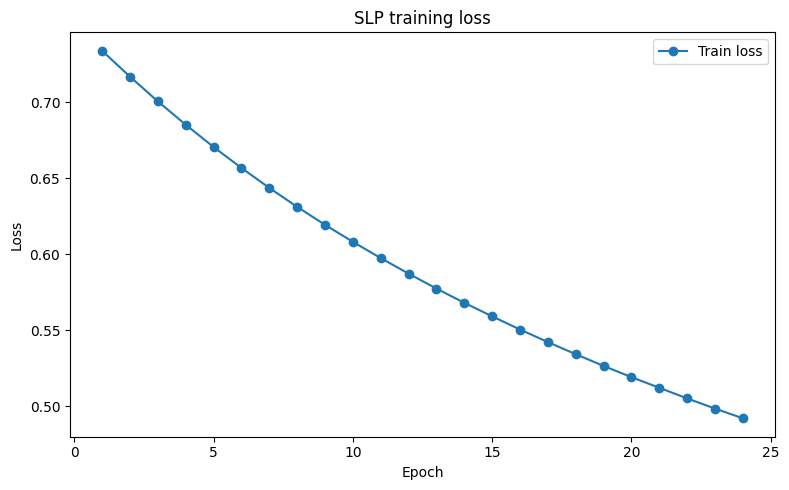

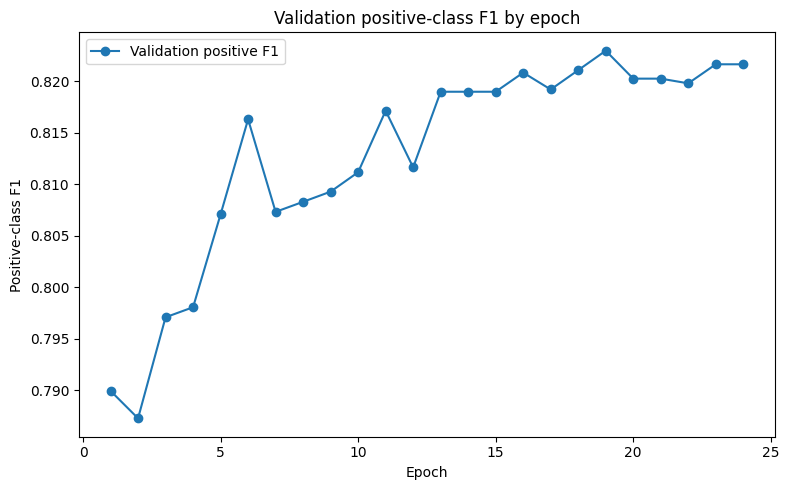

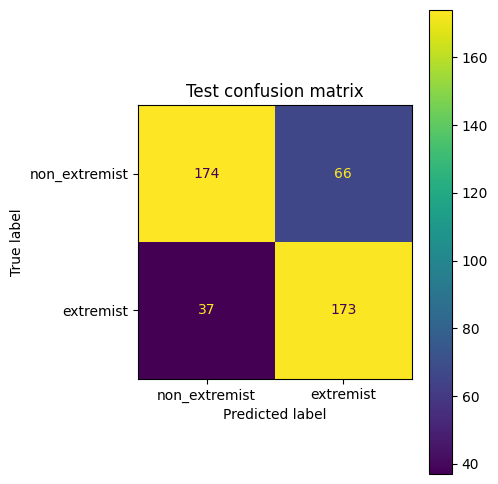

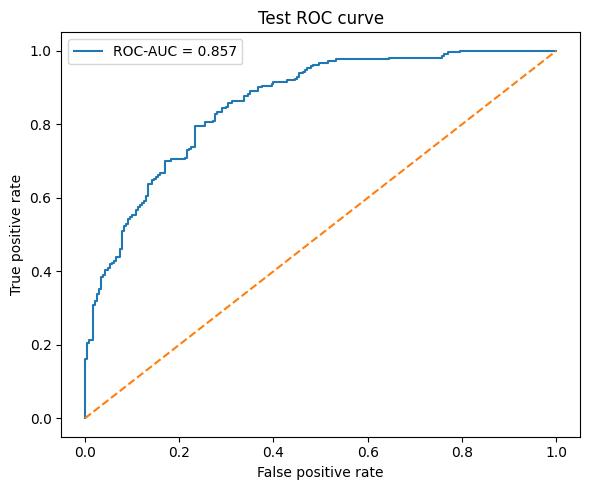

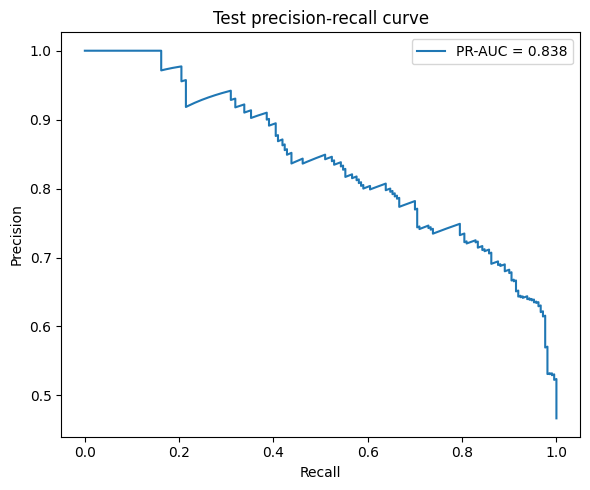

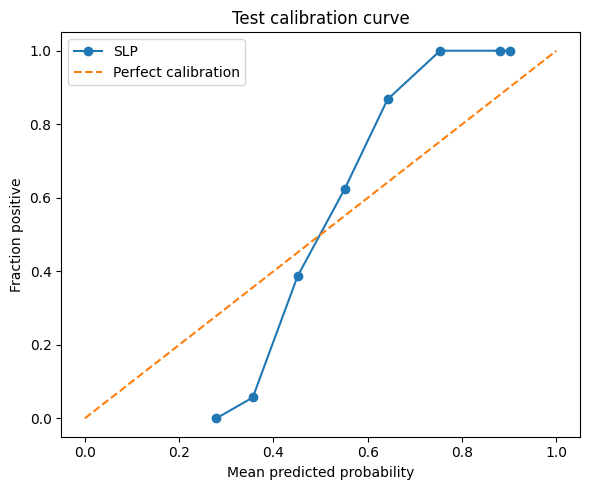

Saved diagnostic plots.


In [13]:
# ============================================================
# 13. Diagnostic plots
# ============================================================

# Training history plot.
if not training_history.empty:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(training_history["epoch"], training_history["train_loss"], marker="o", label="Train loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("SLP training loss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "plots" / "training_loss.png", dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(training_history["epoch"], training_history["val_positive_f1"], marker="o", label="Validation positive F1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Positive-class F1")
    ax.set_title("Validation positive-class F1 by epoch")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "plots" / "validation_f1_by_epoch.png", dpi=200)
    plt.show()

# Confusion matrix.
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["non_extremist", "extremist"]).plot(ax=ax, values_format="d")
ax.set_title("Test confusion matrix")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "plots" / "confusion_matrix_test.png", dpi=200)
plt.show()

# ROC curve.
if test_metrics["roc_auc"] is not None:
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['roc_auc']:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title("Test ROC curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "plots" / "roc_curve_test.png", dpi=200)
    plt.show()

# Precision-recall curve.
if test_metrics["pr_auc"] is not None:
    precision, recall, _ = precision_recall_curve(y_test, test_probs)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(recall, precision, label=f"PR-AUC = {test_metrics['pr_auc']:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Test precision-recall curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "plots" / "pr_curve_test.png", dpi=200)
    plt.show()

# Calibration curve.
try:
    frac_pos, mean_pred = calibration_curve(y_test, test_probs, n_bins=10, strategy="uniform")
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(mean_pred, frac_pos, marker="o", label="SLP")
    ax.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction positive")
    ax.set_title("Test calibration curve")
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "plots" / "calibration_curve_test.png", dpi=200)
    plt.show()
except Exception as e:
    print("Could not create calibration curve:", e)

print("Saved diagnostic plots.")

In [14]:
# ============================================================
# 14. Global linear interpretability
# ============================================================

# Since the SLP is a single linear layer, the logit is exactly:
# logit = bias + sum_j(weight_j * tfidf_j).
#
# This cell saves two forms of attribution:
#
# 1. Direct linear logit contribution:
#       contribution_j = weight_j * tfidf_j
#
#    This exactly decomposes the model logit from a zero baseline.
#
# 2. SHAP-style/background-adjusted linear attribution:
#       attribution_j = weight_j * (tfidf_j - E_train[tfidf_j])
#
#    This explains movement away from the average training-background TF-IDF value.
#    It is analogous to the logic used by linear SHAP under a feature-independence
#    background assumption, but we are computing it directly because the model is linear.

final_model_cpu = final_model.to("cpu")
final_model_cpu.eval()

with torch.no_grad():
    coef = final_model_cpu.linear.weight.detach().cpu().numpy().ravel()
    intercept = float(final_model_cpu.linear.bias.detach().cpu().numpy().ravel()[0])

top_n = CONFIG["explainability"]["top_n_global"]

interpretability_dir = OUTPUT_DIR / "interpretability"
direct_linear_dir = interpretability_dir / "linear_contributions"
shap_style_dir = interpretability_dir / "shap_style_linear"

direct_linear_dir.mkdir(parents=True, exist_ok=True)
shap_style_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 14A. Weight-only global ranking
# ------------------------------------------------------------

coef_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coef,
    "abs_weight": np.abs(coef),
})

top_positive = (
    coef_df
    .sort_values("weight", ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

top_negative = (
    coef_df
    .sort_values("weight", ascending=True)
    .head(top_n)
    .reset_index(drop=True)
)

# Save at root for consistency with earlier notebooks.
top_positive.to_csv(
    interpretability_dir / "top_positive_features_by_weight.csv",
    index=False,
)
top_negative.to_csv(
    interpretability_dir / "top_negative_features_by_weight.csv",
    index=False,
)

# Also save inside the explicit direct-linear folder.
top_positive.to_csv(
    direct_linear_dir / "top_positive_features_by_weight.csv",
    index=False,
)
top_negative.to_csv(
    direct_linear_dir / "top_negative_features_by_weight.csv",
    index=False,
)

# ------------------------------------------------------------
# 14B. Direct contribution importance on actual test examples
# ------------------------------------------------------------

# This captures both the learned weight and the feature occurrence/intensity.
test_direct_contrib = X_test_final.multiply(coef)

mean_direct_contrib_test = np.asarray(test_direct_contrib.mean(axis=0)).ravel()
mean_abs_direct_contrib_test = np.asarray(
    np.abs(test_direct_contrib).mean(axis=0)
).ravel()

direct_contrib_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coef,
    "mean_direct_contribution_test": mean_direct_contrib_test,
    "mean_abs_direct_contribution_test": mean_abs_direct_contrib_test,
})

direct_contrib_df = (
    direct_contrib_df
    .sort_values("mean_abs_direct_contribution_test", ascending=False)
    .reset_index(drop=True)
)

direct_contrib_df.head(top_n).to_csv(
    interpretability_dir / "top_features_by_mean_abs_contribution.csv",
    index=False,
)

direct_contrib_df.head(top_n).to_csv(
    direct_linear_dir / "top_features_by_mean_abs_direct_contribution.csv",
    index=False,
)

direct_explanation_metadata = {
    "explanation_method": "exact_linear_logit_contribution",
    "formula": "tfidf_value * slp_linear_weight",
    "shap_package_used": False,
    "shap_style": False,
    "feature_space": "word_tfidf",
    "explanation_scale": "logit",
    "intercept": intercept,
    "interpretation_note": (
        "Because this SLP has one linear layer, direct feature contributions exactly "
        "decompose the model logit from a zero baseline. These are model-behavior "
        "explanations, not causal claims."
    ),
}

save_json(
    direct_explanation_metadata,
    direct_linear_dir / "explanation_metadata.json",
)

# ------------------------------------------------------------
# 14C. SHAP-style/background-adjusted linear attributions
# ------------------------------------------------------------

# Background expectation is computed from the training split only.
# This avoids test leakage in the explanation baseline.
background_mean_tfidf = np.asarray(X_train_final.mean(axis=0)).ravel()
test_mean_tfidf = np.asarray(X_test_final.mean(axis=0)).ravel()

background_adjusted_mean_contribution = coef * (
    test_mean_tfidf - background_mean_tfidf
)

background_adjusted_global_df = pd.DataFrame({
    "feature": feature_names,
    "weight": coef,
    "train_background_mean_tfidf": background_mean_tfidf,
    "test_mean_tfidf": test_mean_tfidf,
    "background_adjusted_mean_contribution": background_adjusted_mean_contribution,
    "abs_background_adjusted_mean_contribution": np.abs(
        background_adjusted_mean_contribution
    ),
})

background_adjusted_global_df = (
    background_adjusted_global_df
    .sort_values("abs_background_adjusted_mean_contribution", ascending=False)
    .reset_index(drop=True)
)

background_adjusted_global_df.head(top_n).to_csv(
    shap_style_dir / "background_adjusted_global_importance.csv",
    index=False,
)

background_adjusted_metadata = {
    "explanation_method": "shap_style_linear_background_adjusted_attribution",
    "formula": "slp_linear_weight * (tfidf_value - train_background_mean_tfidf)",
    "shap_package_used": False,
    "shap_style": True,
    "feature_space": "word_tfidf",
    "explanation_scale": "logit",
    "background_split": "train",
    "intercept": intercept,
    "interpretation_note": (
        "This is a background-adjusted linear attribution analogous to SHAP LinearExplainer "
        "for a linear model under a feature-independence background assumption. It explains "
        "movement from the average training TF-IDF background on the model logit scale. "
        "These are model-behavior explanations, not causal claims."
    ),
}

save_json(
    background_adjusted_metadata,
    shap_style_dir / "explanation_metadata.json",
)

# ------------------------------------------------------------
# 14D. Combined explanation manifest
# ------------------------------------------------------------

combined_explanation_metadata = {
    "primary_explanation_method": "exact_linear_logit_contribution",
    "secondary_explanation_method": "shap_style_linear_background_adjusted_attribution",
    "shap_package_used": False,
    "feature_space": "word_tfidf",
    "explanation_scale": "logit",
    "methods": {
        "direct_linear": direct_explanation_metadata,
        "shap_style_linear": background_adjusted_metadata,
    },
    "paper_framing_note": (
        "For this SLP, which is a single linear layer over TF-IDF features, exact linear "
        "logit contributions are the primary explanation method. Background-adjusted "
        "linear attributions are also saved to align with SHAP-style linear attribution. "
        "For tree-based models later in the study, Tree SHAP should be used directly."
    ),
}

save_json(
    combined_explanation_metadata,
    interpretability_dir / "explanation_metadata.json",
)

print("Top positive features by weight:")
display(top_positive.head(20))

print("Top negative features by weight:")
display(top_negative.head(20))

print("Top direct mean absolute contribution features:")
display(direct_contrib_df.head(20))

print("Top SHAP-style/background-adjusted global features:")
display(background_adjusted_global_df.head(20))

Top positive features by weight:


,feature,weight,abs_weight
0,kill,0.917824,0.917824
1,murder,0.772017,0.772017
2,them,0.758215,0.758215
3,all,0.738061,0.738061
4,they,0.715024,0.715024
5,let,0.707638,0.707638
6,us,0.702356,0.702356
7,over,0.696281,0.696281
8,attack,0.685122,0.685122
9,genocide,0.659584,0.659584


Top negative features by weight:


,feature,weight,abs_weight
0,bitch,-1.008225,1.008225
1,scum,-0.734736,0.734736
2,ass,-0.672924,0.672924
3,disgusting,-0.668027,0.668027
4,whore,-0.662553,0.662553
5,senseless,-0.660024,0.660024
6,cunt,-0.626538,0.626538
7,trump,-0.596450,0.596450
8,vagina,-0.595456,0.595456
9,stupid,-0.590988,0.590988


Top direct mean absolute contribution features:


,feature,weight,mean_direct_contribution_test,mean_abs_direct_contribution_test
0,bitch,-1.008225,-0.033996,0.033996
1,kill,0.917824,0.026452,0.026452
2,are,0.592091,0.018742,0.018742
3,you,-0.471569,-0.018152,0.018152
4,all,0.738061,0.017513,0.017513
5,they,0.715024,0.016512,0.016512
6,murder,0.772017,0.013972,0.013972
7,of,0.343382,0.013381,0.013381
8,to,0.294498,0.012981,0.012981
9,them,0.758215,0.012845,0.012845


Top SHAP-style/background-adjusted global features:


,feature,weight,train_background_mean_tfidf,test_mean_tfidf,background_adjusted_mean_contribution,abs_background_adjusted_mean_contribution
0,murder,0.772017,0.009717,0.018098,0.006470,0.006470
1,me,-0.448356,0.013266,0.020852,-0.003401,0.003401
2,ill,0.465920,0.003532,0.010369,0.003186,0.003186
3,my,-0.476999,0.016787,0.022218,-0.002590,0.002590
4,shoot,0.644846,0.008103,0.004544,-0.002295,0.002295
5,you,-0.471569,0.043281,0.038493,0.002258,0.002258
6,do,-0.229620,0.017782,0.027422,-0.002214,0.002214
7,traitor,-0.545692,0.009942,0.005907,0.002202,0.002202
8,anymore,0.447827,0.002692,0.007467,0.002138,0.002138
9,all,0.738061,0.026623,0.023728,-0.002137,0.002137


In [15]:
# ============================================================
# 15. Local explanations for selected examples
# ============================================================

def get_local_linear_explanation(
    row_index_in_split,
    X_matrix,
    feature_names,
    coef,
    top_k=15,
):
    """
    Exact direct local explanation for the SLP logit.

    Formula:
        direct_contribution_j = tfidf_j * weight_j

    This includes only nonzero TF-IDF features, which is usually the most readable
    local explanation for text.
    """
    row = X_matrix[row_index_in_split]
    contrib = row.multiply(coef).tocoo()

    if contrib.nnz == 0:
        return {
            "top_positive_features": [],
            "top_negative_features": [],
        }

    local_df = pd.DataFrame({
        "feature_index": contrib.col,
        "feature_name": feature_names[contrib.col],
        "tfidf_value": np.asarray(row[:, contrib.col].todense()).ravel(),
        "weight": coef[contrib.col],
        "direct_contribution": contrib.data,
    })

    top_pos = (
        local_df
        .sort_values("direct_contribution", ascending=False)
        .head(top_k)
        .to_dict(orient="records")
    )

    top_neg = (
        local_df
        .sort_values("direct_contribution", ascending=True)
        .head(top_k)
        .to_dict(orient="records")
    )

    return {
        "top_positive_features": top_pos,
        "top_negative_features": top_neg,
    }


def get_local_background_adjusted_explanation(
    row_index_in_split,
    X_matrix,
    feature_names,
    coef,
    background_mean,
    top_k=15,
    include_absent_features=True,
):
    """
    SHAP-style/background-adjusted local explanation for the SLP logit.

    Formula:
        background_adjusted_contribution_j =
            weight_j * (tfidf_j - train_background_mean_tfidf_j)

    If include_absent_features=True, this considers all TF-IDF features, including
    features absent from the current document. This is closer to a true
    background-adjusted attribution view, but may be less intuitive for text.

    If include_absent_features=False, this considers only nonzero features in the
    current document, which is more readable but less complete.
    """
    row = X_matrix[row_index_in_split]

    if include_absent_features:
        # Efficiently compute full background-adjusted contribution without
        # densifying the entire sparse matrix.
        #
        # Start with contribution for zero-valued features:
        # coef * (0 - background_mean)
        adjusted_contrib = -coef * background_mean

        # Then update the nonzero entries:
        # coef * (tfidf_value - background_mean)
        row_coo = row.tocoo()
        adjusted_contrib = adjusted_contrib.copy()
        adjusted_contrib[row_coo.col] = coef[row_coo.col] * (
            row_coo.data - background_mean[row_coo.col]
        )

        top_pos_idx = np.argsort(adjusted_contrib)[::-1][:top_k]
        top_neg_idx = np.argsort(adjusted_contrib)[:top_k]

        row_nonzero_dict = {
            int(col): float(val)
            for col, val in zip(row_coo.col, row_coo.data)
        }

        def build_records(indices):
            records = []
            for idx in indices:
                idx = int(idx)
                records.append({
                    "feature_index": idx,
                    "feature_name": feature_names[idx],
                    "tfidf_value": float(row_nonzero_dict.get(idx, 0.0)),
                    "feature_present_in_document": bool(idx in row_nonzero_dict),
                    "train_background_mean_tfidf": float(background_mean[idx]),
                    "weight": float(coef[idx]),
                    "background_adjusted_contribution": float(adjusted_contrib[idx]),
                })
            return records

        return {
            "top_positive_features": build_records(top_pos_idx),
            "top_negative_features": build_records(top_neg_idx),
        }

    # Present-feature-only version.
    row_coo = row.tocoo()

    if row_coo.nnz == 0:
        return {
            "top_positive_features": [],
            "top_negative_features": [],
        }

    feature_idx = row_coo.col
    tfidf_values = row_coo.data

    adjusted_contrib = coef[feature_idx] * (
        tfidf_values - background_mean[feature_idx]
    )

    local_df = pd.DataFrame({
        "feature_index": feature_idx,
        "feature_name": feature_names[feature_idx],
        "tfidf_value": tfidf_values,
        "feature_present_in_document": True,
        "train_background_mean_tfidf": background_mean[feature_idx],
        "weight": coef[feature_idx],
        "background_adjusted_contribution": adjusted_contrib,
    })

    top_pos = (
        local_df
        .sort_values("background_adjusted_contribution", ascending=False)
        .head(top_k)
        .to_dict(orient="records")
    )

    top_neg = (
        local_df
        .sort_values("background_adjusted_contribution", ascending=True)
        .head(top_k)
        .to_dict(orient="records")
    )

    return {
        "top_positive_features": top_pos,
        "top_negative_features": top_neg,
    }


def compact_direct_feature_list(records):
    return [
        {
            "feature": r["feature_name"],
            "tfidf": float(r["tfidf_value"]),
            "weight": float(r["weight"]),
            "direct_contribution": float(r["direct_contribution"]),
        }
        for r in records
    ]


def compact_background_adjusted_feature_list(records):
    return [
        {
            "feature": r["feature_name"],
            "tfidf": float(r["tfidf_value"]),
            "feature_present_in_document": bool(r["feature_present_in_document"]),
            "train_background_mean_tfidf": float(r["train_background_mean_tfidf"]),
            "weight": float(r["weight"]),
            "background_adjusted_contribution": float(
                r["background_adjusted_contribution"]
            ),
        }
        for r in records
    ]


def select_examples_for_local_explanations(pred_df, max_total=120):
    selected_parts = []

    fp = (
        pred_df[pred_df["error_type"] == "false_positive"]
        .sort_values("y_prob", ascending=False)
        .head(25)
    )
    selected_parts.append(
        fp.assign(selection_bucket="high_confidence_false_positive")
    )

    fn = (
        pred_df[pred_df["error_type"] == "false_negative"]
        .sort_values("y_prob", ascending=True)
        .head(25)
    )
    selected_parts.append(
        fn.assign(selection_bucket="high_confidence_false_negative")
    )

    pred_df2 = pred_df.copy()
    pred_df2["distance_to_threshold"] = np.abs(
        pred_df2["y_prob"] - pred_df2["threshold"]
    )

    near_fp = (
        pred_df2[pred_df2["error_type"] == "false_positive"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(
        near_fp.assign(selection_bucket="near_threshold_false_positive")
    )

    near_fn = (
        pred_df2[pred_df2["error_type"] == "false_negative"]
        .sort_values("distance_to_threshold", ascending=True)
        .head(25)
    )
    selected_parts.append(
        near_fn.assign(selection_bucket="near_threshold_false_negative")
    )

    tp = (
        pred_df[pred_df["error_type"] == "true_positive"]
        .sort_values("y_prob", ascending=False)
        .head(15)
    )
    tn = (
        pred_df[pred_df["error_type"] == "true_negative"]
        .sort_values("y_prob", ascending=True)
        .head(15)
    )

    selected_parts.append(tp.assign(selection_bucket="high_confidence_true_positive"))
    selected_parts.append(tn.assign(selection_bucket="high_confidence_true_negative"))

    selected = (
        pd.concat(selected_parts, axis=0)
        .drop_duplicates(subset=["row_id"])
        .head(max_total)
        .reset_index(drop=True)
    )

    return selected


selected_pred_examples = select_examples_for_local_explanations(
    test_predictions,
    max_total=CONFIG["explainability"]["max_local_examples_total"],
)

test_row_position = {rid: i for i, rid in enumerate(test_df[id_col].tolist())}

local_rows = []
for _, pred_row in selected_pred_examples.iterrows():
    rid = pred_row["row_id"]
    pos = test_row_position[rid]

    direct_explanation = get_local_linear_explanation(
        row_index_in_split=pos,
        X_matrix=X_test_final,
        feature_names=feature_names,
        coef=coef,
        top_k=CONFIG["explainability"]["top_k_local_features"],
    )

    background_adjusted_explanation = get_local_background_adjusted_explanation(
        row_index_in_split=pos,
        X_matrix=X_test_final,
        feature_names=feature_names,
        coef=coef,
        background_mean=background_mean_tfidf,
        top_k=CONFIG["explainability"]["top_k_local_features"],
        include_absent_features=CONFIG["explainability"][
            "background_adjusted_include_absent_features_for_local"
        ],
    )

    record = {
        "run_id": RUN_ID,
        "technique": TECHNIQUE_NAME,
        "row_id": rid,
        "selection_bucket": pred_row["selection_bucket"],
        "y_true": int(pred_row["y_true"]),
        "y_pred": int(pred_row["y_pred"]),
        "y_prob": float(pred_row["y_prob"]),
        "threshold": float(pred_row["threshold"]),
        "error_type": pred_row["error_type"],

        # Exact direct local logit contributions
        "direct_top_positive_features_json": json.dumps(
            compact_direct_feature_list(
                direct_explanation["top_positive_features"]
            )
        ),
        "direct_top_negative_features_json": json.dumps(
            compact_direct_feature_list(
                direct_explanation["top_negative_features"]
            )
        ),

        # Backward-compatible names from the previous notebook version
        "top_positive_features_json": json.dumps(
            compact_direct_feature_list(
                direct_explanation["top_positive_features"]
            )
        ),
        "top_negative_features_json": json.dumps(
            compact_direct_feature_list(
                direct_explanation["top_negative_features"]
            )
        ),

        # SHAP-style/background-adjusted local attributions
        "background_adjusted_top_positive_features_json": json.dumps(
            compact_background_adjusted_feature_list(
                background_adjusted_explanation["top_positive_features"]
            )
        ),
        "background_adjusted_top_negative_features_json": json.dumps(
            compact_background_adjusted_feature_list(
                background_adjusted_explanation["top_negative_features"]
            )
        ),
    }

    if CONFIG["explainability"]["include_text_preview"]:
        text_value = test_df.loc[test_df[id_col] == rid, text_col].iloc[0]
        record["text_preview"] = text_value[
            :CONFIG["explainability"]["text_preview_chars"]
        ]

    local_rows.append(record)

local_explanations = pd.DataFrame(local_rows)

# Save combined local explanations at root for easy access.
local_explanations.to_csv(
    OUTPUT_DIR / "interpretability" / "local_explanations_selected_examples.csv",
    index=False,
)

# Save method-specific copies.
direct_linear_dir = OUTPUT_DIR / "interpretability" / "linear_contributions"
shap_style_dir = OUTPUT_DIR / "interpretability" / "shap_style_linear"
direct_linear_dir.mkdir(parents=True, exist_ok=True)
shap_style_dir.mkdir(parents=True, exist_ok=True)

direct_cols = [
    "run_id",
    "technique",
    "row_id",
    "selection_bucket",
    "y_true",
    "y_pred",
    "y_prob",
    "threshold",
    "error_type",
    "direct_top_positive_features_json",
    "direct_top_negative_features_json",
]

background_adjusted_cols = [
    "run_id",
    "technique",
    "row_id",
    "selection_bucket",
    "y_true",
    "y_pred",
    "y_prob",
    "threshold",
    "error_type",
    "background_adjusted_top_positive_features_json",
    "background_adjusted_top_negative_features_json",
]

local_explanations[direct_cols].to_csv(
    direct_linear_dir / "local_explanations_selected_examples.csv",
    index=False,
)

local_explanations[background_adjusted_cols].to_csv(
    shap_style_dir / "background_adjusted_local_explanations_selected_examples.csv",
    index=False,
)

print("Saved combined local explanations:")
print("-", OUTPUT_DIR / "interpretability" / "local_explanations_selected_examples.csv")

print("Saved direct local explanations:")
print("-", direct_linear_dir / "local_explanations_selected_examples.csv")

print("Saved SHAP-style/background-adjusted local explanations:")
print("-", shap_style_dir / "background_adjusted_local_explanations_selected_examples.csv")

display(local_explanations.head())

Saved combined local explanations:
- /kaggle/working/experiments/SLP_TF-IDF/interpretability/local_explanations_selected_examples.csv
Saved direct local explanations:
- /kaggle/working/experiments/SLP_TF-IDF/interpretability/linear_contributions/local_explanations_selected_examples.csv
Saved SHAP-style/background-adjusted local explanations:
- /kaggle/working/experiments/SLP_TF-IDF/interpretability/shap_style_linear/background_adjusted_local_explanations_selected_examples.csv


,run_id,technique,row_id,selection_bucket,y_true,y_pred,y_prob,threshold,error_type,direct_top_positive_features_json,direct_top_negative_features_json,top_positive_features_json,top_negative_features_json,background_adjusted_top_positive_features_json,background_adjusted_top_negative_features_json
0,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000917,high_confidence_false_positive,0,1,0.674952,0.48,false_positive,"[{""feature"": ""muslim"", ""tfidf"": 0.189098383283...","[{""feature"": ""like"", ""tfidf"": 0.12858022796073...","[{""feature"": ""muslim"", ""tfidf"": 0.189098383283...","[{""feature"": ""like"", ""tfidf"": 0.12858022796073...","[{""feature"": ""muslim"", ""tfidf"": 0.189098383283...","[{""feature"": ""like"", ""tfidf"": 0.12858022796073..."
1,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000134,high_confidence_false_positive,0,1,0.653361,0.48,false_positive,"[{""feature"": ""murder"", ""tfidf"": 0.204639341928...","[{""feature"": ""gang"", ""tfidf"": 0.37235944434281...","[{""feature"": ""murder"", ""tfidf"": 0.204639341928...","[{""feature"": ""gang"", ""tfidf"": 0.37235944434281...","[{""feature"": ""murder"", ""tfidf"": 0.204639341928...","[{""feature"": ""gang"", ""tfidf"": 0.37235944434281..."
2,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000078,high_confidence_false_positive,0,1,0.647424,0.48,false_positive,"[{""feature"": ""murder"", ""tfidf"": 0.440514601884...","[{""feature"": ""face"", ""tfidf"": 0.41635693320849...","[{""feature"": ""murder"", ""tfidf"": 0.440514601884...","[{""feature"": ""face"", ""tfidf"": 0.41635693320849...","[{""feature"": ""murder"", ""tfidf"": 0.440514601884...","[{""feature"": ""face"", ""tfidf"": 0.41635693320849..."
3,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000213,high_confidence_false_positive,0,1,0.646838,0.48,false_positive,"[{""feature"": ""attack"", ""tfidf"": 0.205028967224...","[{""feature"": ""here"", ""tfidf"": 0.26187743667880...","[{""feature"": ""attack"", ""tfidf"": 0.205028967224...","[{""feature"": ""here"", ""tfidf"": 0.26187743667880...","[{""feature"": ""attack"", ""tfidf"": 0.205028967224...","[{""feature"": ""here"", ""tfidf"": 0.26187743667880..."
4,SLP_TF-IDF_20260620T232103Z,SLP_TF-IDF,ex_000353,high_confidence_false_positive,0,1,0.622880,0.48,false_positive,"[{""feature"": ""muslim"", ""tfidf"": 0.191975392518...","[{""feature"": ""religion"", ""tfidf"": 0.2262142668...","[{""feature"": ""muslim"", ""tfidf"": 0.191975392518...","[{""feature"": ""religion"", ""tfidf"": 0.2262142668...","[{""feature"": ""muslim"", ""tfidf"": 0.191975392518...","[{""feature"": ""religion"", ""tfidf"": 0.2262142668..."


In [16]:
# ============================================================
# 16. Error-analysis outputs
# ============================================================

error_df = test_predictions.copy()
error_df["abs_distance_to_threshold"] = np.abs(error_df["y_prob"] - error_df["threshold"])


def confidence_bucket(row):
    if row["abs_distance_to_threshold"] <= CONFIG["error_analysis"]["near_threshold_margin"]:
        return "near_threshold"
    if row["y_prob"] >= 0.90 or row["y_prob"] <= 0.10:
        return "high_confidence"
    return "moderate_confidence"


error_df["confidence_bucket"] = error_df.apply(confidence_bucket, axis=1)
error_df["manual_error_category"] = ""
error_df["manual_notes"] = ""

if not local_explanations.empty:
    feature_cols = local_explanations[
        ["row_id", "top_positive_features_json", "top_negative_features_json"]
    ].drop_duplicates("row_id")
    error_df = error_df.merge(feature_cols, on="row_id", how="left")

if CONFIG["error_analysis"]["include_text_preview"]:
    text_lookup = test_df[[id_col, text_col]].copy()
    text_lookup["text_preview"] = text_lookup[text_col].str.slice(0, CONFIG["error_analysis"]["text_preview_chars"])
    error_df = error_df.merge(text_lookup[[id_col, "text_preview"]], left_on="row_id", right_on=id_col, how="left")
    if id_col in error_df.columns and id_col != "row_id":
        error_df = error_df.drop(columns=[id_col])

error_df.to_csv(OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv", index=False)

review_parts = []
n = CONFIG["error_analysis"]["examples_per_bucket"]

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("y_prob", ascending=False)
    .head(n)
    .assign(review_bucket="highest_confidence_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("y_prob", ascending=True)
    .head(n)
    .assign(review_bucket="highest_confidence_false_negative")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_positive"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_positive")
)

review_parts.append(
    error_df[error_df["error_type"] == "false_negative"]
    .sort_values("abs_distance_to_threshold", ascending=True)
    .head(n)
    .assign(review_bucket="near_threshold_false_negative")
)

selected_review_examples = (
    pd.concat(review_parts, axis=0)
    .drop_duplicates(subset=["row_id"])
    .reset_index(drop=True)
)

selected_review_examples.to_csv(
    OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv",
    index=False,
)

print("Saved error analysis files:")
print("-", OUTPUT_DIR / "error_analysis" / "error_analysis_test.csv")
print("-", OUTPUT_DIR / "error_analysis" / "selected_examples_for_review.csv")

display(error_df["error_type"].value_counts().to_frame("count"))
display(error_df.groupby(["error_type", "confidence_bucket"]).size().reset_index(name="count"))

Saved error analysis files:
- /kaggle/working/experiments/SLP_TF-IDF/error_analysis/error_analysis_test.csv
- /kaggle/working/experiments/SLP_TF-IDF/error_analysis/selected_examples_for_review.csv


,count
error_type,
true_negative,174
true_positive,173
false_positive,66
false_negative,37


,error_type,confidence_bucket,count
0,false_negative,moderate_confidence,17
1,false_negative,near_threshold,20
2,false_positive,moderate_confidence,40
3,false_positive,near_threshold,26
4,true_negative,moderate_confidence,136
5,true_negative,near_threshold,38
6,true_positive,high_confidence,2
7,true_positive,moderate_confidence,138
8,true_positive,near_threshold,33


In [17]:
# ============================================================
# 17. Save experiment metadata and output README
# ============================================================

metadata = {
    "run_id": RUN_ID,
    "technique": TECHNIQUE_NAME,
    "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",
    "project_name": CONFIG["project_name"],
    "dataset_version": CONFIG["dataset_version"],
    "split_version": CONFIG["split_version"],
    "random_seed": CONFIG["random_seed"],
    "processed_dataset_path": str(processed_dataset_path),
    "processed_dataset_sha256_16": sha256_file(processed_dataset_path),
    "split_assignments_path": str(split_assignments_path),
    "split_assignments_sha256_16": sha256_file(split_assignments_path),
    "dataset_manifest": dataset_manifest,

    "software_environment": {
        "python_version": platform.python_version(),
        "platform": platform.platform(),
        "numpy_version": np.__version__,
        "pandas_version": pd.__version__,
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    },
    "sklearn_version": __import__("sklearn").__version__,

    "model_selection": {
        "ablation_split": "validation",
        "primary_selection_metric": "positive_f1",
        "test_set_used_for_selection": False,
    },

    "final_evaluation": {
        "test_split_used_once_after_selection": True,
        "threshold_selected_on": "validation",
    },

    "explainability_protocol": {
        "primary_method": "exact_linear_logit_contribution",
        "primary_formula": "tfidf_value * slp_linear_weight",
        "secondary_method": "shap_style_linear_background_adjusted_attribution",
        "secondary_formula": "slp_linear_weight * (tfidf_value - train_background_mean_tfidf)",
        "shap_package_used_for_slp": False,
        "explanation_scale": "logit",
        "feature_space": "word_tfidf",
        "background_split": "train",
        "note": (
            "Because the SLP is a single linear layer over TF-IDF features, exact linear "
            "contributions decompose the model logit. Background-adjusted attributions "
            "are also saved to align with SHAP-style linear attribution logic. These "
            "are model-behavior explanations, not causal explanations."
        ),
    },

    "outputs": {
        "config": "config.json",
        "best_config": "best_config.json",
        "ablation_results": "ablation/ablation_results.csv",
        "training_history": "training_history.csv",
        "metrics_validation": "metrics_validation.json",
        "metrics_test": "metrics_test.json",
        "predictions_validation": "predictions_validation.csv",
        "predictions_test": "predictions_test.csv",
        "model_artifacts": "model_artifacts/",
        "plots": "plots/",
        "interpretability": "interpretability/",
        "direct_linear_interpretability": "interpretability/linear_contributions/",
        "shap_style_linear_interpretability": "interpretability/shap_style_linear/",
        "error_analysis": "error_analysis/",
    },
}

save_json(metadata, OUTPUT_DIR / "metadata.json")

readme_text = f"""# {TECHNIQUE_NAME} outputs

This folder contains the standardized outputs for the `{TECHNIQUE_NAME}` experiment.

## Research protocol

- Dataset: `{CONFIG['dataset_version']}`
- Split version: `{CONFIG['split_version']}`
- Model selection: validation-only
- Primary selection metric: validation positive-class F1
- Threshold selection: validation-only
- Final test evaluation: held-out test split only

## Model

This model is a single-layer PyTorch classifier over TF-IDF features. It is a linear model on sparse lexical features, trained with binary cross-entropy with logits.

## Explainability protocol

Because this SLP is a single linear layer over TF-IDF features, the model logit is exactly:

`logit = bias + sum_j(weight_j * tfidf_j)`

This output folder saves two explanation styles:

1. Exact direct linear logit contributions

   Formula:

   `direct_contribution_j = weight_j * tfidf_j`

   These exactly decompose the model logit from a zero baseline.

2. SHAP-style/background-adjusted linear attributions

   Formula:

   `background_adjusted_contribution_j = weight_j * (tfidf_j - train_background_mean_tfidf_j)`

   These explain movement from the average training-background TF-IDF value on the logit scale. The SHAP package is not used for this SLP notebook because the model is linear and the attribution can be computed directly.

These explanations describe model behavior, not causal importance or true extremist intent.

## Key files

- `metrics_test.json`: final held-out test metrics
- `predictions_test.csv`: standardized row-level test predictions
- `ablation/ablation_results.csv`: validation-only tuning results
- `best_config.json`: selected model configuration
- `training_history.csv`: final model training history
- `model_artifacts/`: trained model/vectorizer/feature names/threshold
- `interpretability/`: combined explanation outputs
- `interpretability/linear_contributions/`: exact direct linear logit-contribution outputs
- `interpretability/shap_style_linear/`: SHAP-style/background-adjusted linear attribution outputs
- `error_analysis/`: tables for false-positive/false-negative review
"""

with open(OUTPUT_DIR / "README_outputs.md", "w") as f:
    f.write(readme_text)

print("Saved metadata and output README.")
print("Output directory:", OUTPUT_DIR)

Saved metadata and output README.
Output directory: /kaggle/working/experiments/SLP_TF-IDF


/tmp/ipykernel_22/3125297658.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": dt.datetime.utcnow().replace(microsecond=0).isoformat() + "Z",


In [18]:
# ============================================================
# 18. Zip output folder for Kaggle download / Google Drive archive
# ============================================================

zip_base = Path("/kaggle/working") / f"{TECHNIQUE_NAME}_outputs"
zip_path = shutil.make_archive(
    base_name=str(zip_base),
    format="zip",
    root_dir=OUTPUT_DIR,
)

print("Created output zip:", zip_path)

Created output zip: /kaggle/working/SLP_TF-IDF_outputs.zip
